[![logo](https://climate.copernicus.eu/sites/default/files/custom-uploads/branding/LogoLine_horizon_C3S.png)](https://climate.copernicus.eu)

# Exclusion layers

In the current operational implementations of the C3S Energy service, wind and solar power indicators (SPV, WON, WOF) are computed at every grid point of the domain and aggregated without making use of exclusion layers. From a computational perspective, in fact, all grid points can be considered when performing spatial aggregation over a country or sub-country region. It is also true, however, that this approach does not account for the actual suitability of the locations, whether it is a city or a mountainous area, or whether a power plant is present or can be installed. This means that energy indicators, such as the capacity factor averaged over an area, may be over- or under-estimated compared to a realistic value, depending on the typology of the restricted areas. To address this limitation, the Service has developed and shared (but not applied) several ‘exclusion layers’ that define criteria for restricted areas, so that users can eventually apply them if needed, according to their local requirements. 

These exclusion criteria comprise: 

* Protected Areas 
* Polar Areas 
* Urban areas 
* Water and continent areas 
* High slope areas 
* High elevation areas 
* Distance to shore areas 
* Combination of restricted areas (for wind power and SPV modelling).

In this notebook we are going to compute aggregated values for SPV at country level (ADM0 mask) by performing a more accurate computation using a combination of several exclusion layer masks.

## Learning objectives 🎯

Throughout this notebook, you will:
* Understand the limitations of current methodology (lack of exclusion layers);
* Gain hands-on experience in optionally applying exclusion criteria to refine spatial computations.

## Target Audience 🎯

**Anyone** interested in learning how to use the different types of exclusion layers available for more realistic modelling of energy indicators.

## Prepare your environment

### Import required packages

We start by importing some useful libraries. These include: [os](https://docs.python.org/3/library/os.html), which provides a way to interact with the operating system and it is used here to manipulate paths; [pandas](https://pandas.pydata.org/), one of the most common and easy to use tools for data analysis and manipulation; [numpy](https://numpy.org/doc/stable/), fundamental for numerical computing; [matplotlib](https://matplotlib.org/), a standard library for creating visualizations in Python; [xarray](https://docs.xarray.dev/en/stable/index.html), a library to work with multidimensional arrays in NetCDF format.

In [1]:
# importing libraries
import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
# import dask

## Load the data

First of all we are going to load a gridded dataset of SPV (solar photovoltaic capacity factor) for a given year and month, using open_mfdataset method:

In [4]:
# define year and month
year = 2015
month = 1
# define directory containing ERA5 .nc files
base_dir = "./data/nc/spv/"
# find file path
file_path = sorted(glob.glob(os.path.join(base_dir, f"*S{year}{month:02d}*.nc")))[0]
#print(file_path)
ds_spv = xr.open_dataset((file_path), chunks={'time': 24})
ds_spv

<xarray.Dataset> Size: 6GB
Dimensions:    (time: 744, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2015-01-01 ... 2015-01-31T23:00:00
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
Data variables:
    spv_cf     (time, latitude, longitude) float64 6GB dask.array<chunksize=(24, 721, 1440), meta=np.ndarray>
Attributes:
    title:        Solar PV capacity factor
    institution:  Copernicus Climate Change Service, Sectoral Information Sys...
    source:       ERA5 reanalysis data provided by ECMWF (https://www.ecmwf.i...
    history:      2025-05-13 13:48:25 GMT by write_hist_xr_to_nc-0.1.dev51+g1...
    references:    
    Conventions:  CF-1.12-draft

#### Loading exclusion layers masks

Now we are going to load some exclusion layers masks that will be combined in order to create a final mask to be applied to spv dataset in order to compute aggregated values at country level. We will use:
* the protected area mask (PRA); which is the mask for excluding protected areas. Values equal to 1 represent protected areas pixels.
* the polar area mask (POA), where values equal to 1 represent polar areas pixels;
* the high slope area mask (HSA), Mask for excluding high slope areas where values equal to 1 represent cells with high slopes coverage (equal or higher than 60%);
* the high elevation area mask (HEA), Mask for excluding high elevation areas. Values equal to 1 represent a high elevation pixel;
* the water and continental area mask (WCA): Mask for excluding inland water areas. Differently from other masks, this NetCDF has a three-value format, where 0 represents land, 1 represents ocean and 2 corresponds to inland waters. 

In [5]:
exc_dir = "./data/nc/exc_layers"
daPRA = xr.open_dataset(f"{exc_dir}/H_WDPA_UNEP_NA--_PRA_0000m_Glob_025d_S202105010000_E202112010000_INV_MAP_NA-_NA-_NA-_NA-_NA_NA---_NA---_NA---.nc").prot_a
daPOA = xr.open_dataset(f"{exc_dir}/H_LCCS_UNFA_NA--_POA_0000m_Glob_025d_S202105010000_E202112010000_INV_MAP_NA-_NA-_NA-_NA-_NA_NA---_NA---_NA---.nc").polar_a
daHEA = xr.open_dataset(f"{exc_dir}/H_ETP1_NOAA_NA--_HEA_0000m_Glob_025d_S202105010000_E202112010000_INV_MAP_NA-_NA-_NA-_NA-_NA_NA---_NA---_NA---.nc").hele_a
daHSA = xr.open_dataset(f"{exc_dir}/H_ETP1_NOAA_NA--_HSA_0000m_Glob_025d_S202105010000_E202112010000_INV_MAP_NA-_NA-_NA-_NA-_NA_NA---_NA---_NA---.nc").hslo_a
daWCA = xr.open_dataset(f"{exc_dir}/H_ERA5_ECMW_T639_WCA_0000m_Glob_025d_S202105010000_E202112010000_INV_MAP_NA-_NA-_NA-_NA-_NA_NA---_NA---_NA---.nc").watr_b

(0.0, 1.0, 0.0, 1.0)

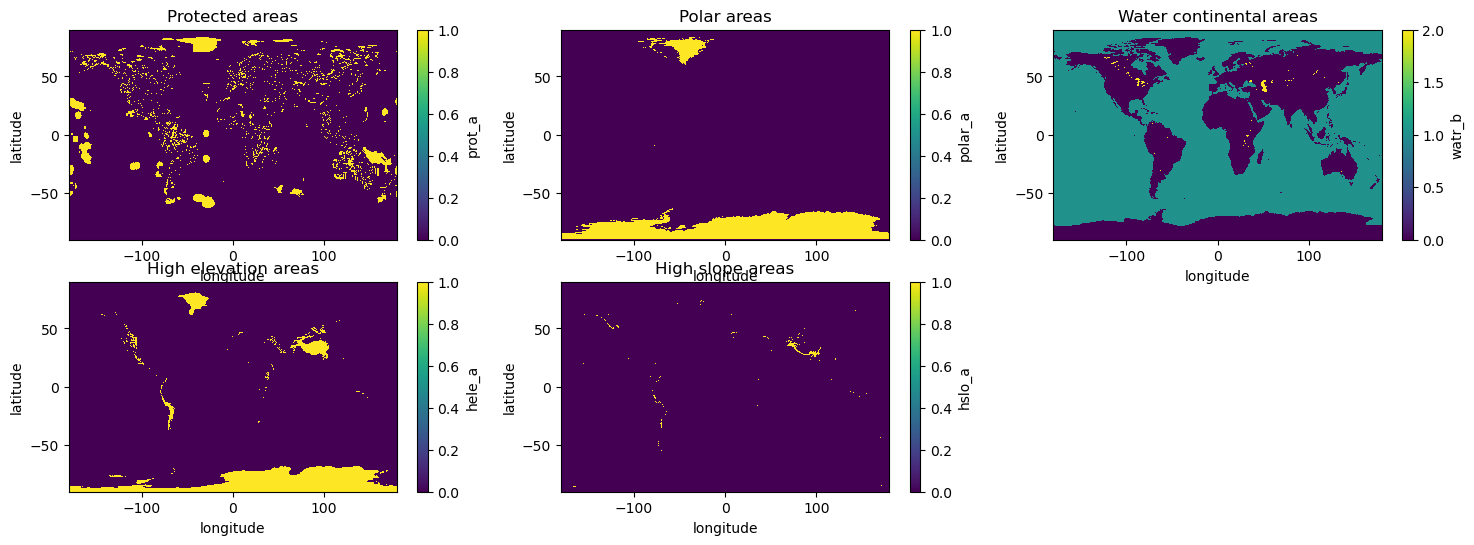

In [6]:
fig,ax = plt.subplots(2,3, figsize=(18,6))
daPRA.plot(ax=ax[0,0])
ax[0,0].set_title("Protected areas")
daPOA.plot(ax=ax[0,1])
ax[0,1].set_title("Polar areas")
daHEA.plot(ax=ax[1,0])
ax[1,0].set_title("High elevation areas")
daHSA.plot(ax=ax[1,1])
ax[1,1].set_title("High slope areas")
daWCA.plot(ax=ax[0,2])
ax[0,2].set_title("Water continental areas")
ax[1,2].axis('off')

A little modification is necessary in order to use the water continental mask, we have to set value equal to one where they are equal to two (internal waters, lakes) in order to exclude them in the aggregation procedure.

In [7]:
daWCA = xr.where(daWCA==2, 1, daWCA)

#### Build the spv mask

Now we are ready to build the mask by combining the various exclusion layers we have just loaded. It is simply a sum of all masks, followed by applicaytion of xr.where method. If the values of the pixels are all equal to zero, then the final vaue will be zero and pixel will be included in the following aggregation. Application of xr.where will set values where the sum is greater than zero to one, and those pixels will be excluded from the aggregation.

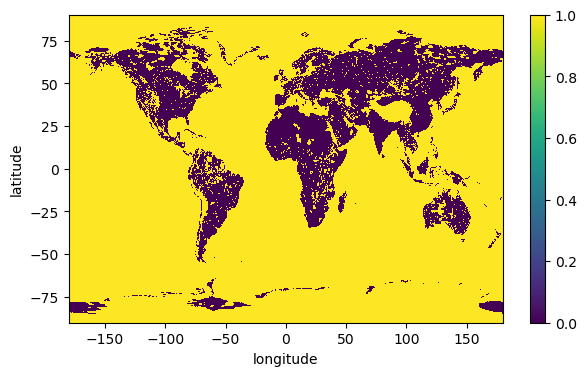

In [8]:
daSum = daPRA + daHEA + daHSA + daPOA + daWCA
spv_mask = xr.where(daSum > 0, 1, daSum)
spv_mask.plot(figsize=(7,4))

Now we are going to apply the mask to our spv gridded dataset previously loaded. But before doing that, we can notice that longitude values of mask goes spans [180, 180], whereas that of spv spans [0,360]. So we need to convert the spv longitude in order to be able to apply the mask correctly. To do this, we will define a function to handle the calculation:

In [9]:
# function to convert longitude values from 0, 360 to -180,180
def shift_longitude(ds):
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180))
    return ds.sortby('longitude')

# apply spv exclusion layers mask to spv
da_spv = shift_longitude(ds_spv.spv_cf)#.compute()

We can apply the mask using xr.where method (this operation may take ~ 5 minutes):

In [10]:
da_spv_masked = xr.where(spv_mask, np.nan, da_spv)#.compute()
da_spv_masked

<xarray.DataArray (latitude: 721, longitude: 1440, time: 744)> Size: 6GB
dask.array<where, shape=(721, 1440, 744), dtype=float64, chunksize=(721, 1440, 24), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * time       (time) datetime64[ns] 6kB 2015-01-01 ... 2015-01-31T23:00:00

And now we plot spv monthly average values for all pixels both with and without exclusion layers, in order to appreciate the difference:

Text(0.5, 1.0, 'with exclusion layers')

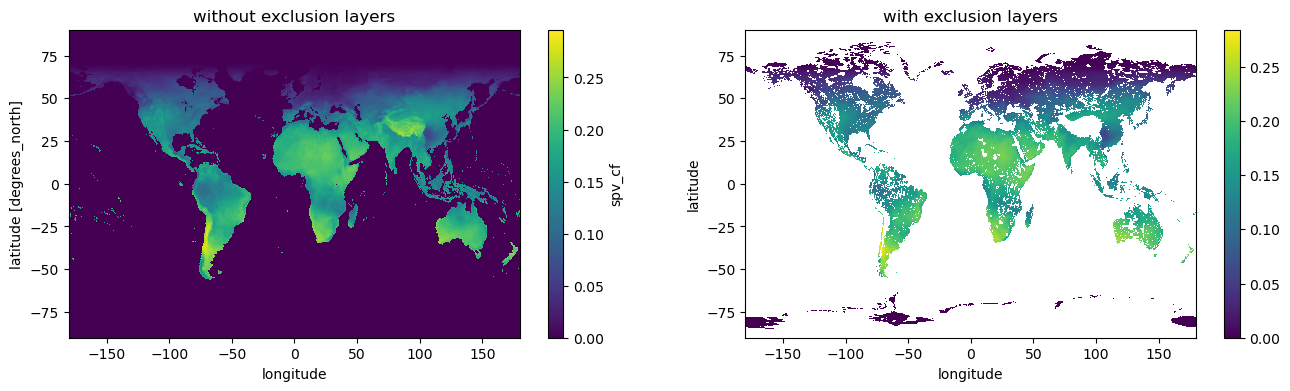

In [11]:
fig, ax = plt.subplots(1,2, figsize=(16,4))
plt.title("spv capacity factor")
da_spv.mean(dim='time').plot(ax=ax[0])
ax[0].set_title("without exclusion layers")
da_spv_masked.mean(dim='time').plot(ax=ax[1])
ax[1].set_title("with exclusion layers")

From the plots we can see that our computation is correct and many pixels values are now nan.

## Aggregated SPV at country level

Next we are going to compute aggregated spv at country level by making use of our masked spv gridded data. First of all we load ADM0 mask and selcet a country:

In [13]:
# path to ADM0 mask netcdf
adm0_path = "./data/nc/agg_mask/ANCI_ADM0B-mask_C3S2LOT1_025d_v1.00.nc"
adm0_mask = xr.open_dataset(adm0_path).mask
# shift longitude
adm0_mask = shift_longitude(adm0_mask)

As one can see the mask dataarray contains float64 values and has a coordinate called 'region' that corresponds to ADM0 countries definitions. The mask is float because it considers the fraction of a pixel contained in a given region. We are going to select one of those region and plot the datarray:

In [14]:
selected_region = 'FR'
lat_slice, lon_slice = slice(47, 45), slice(13, 17)
lat_slice, lon_slice = slice(51, 41), slice(-5, 10)
region_mask = adm0_mask.sel(region=selected_region)
# replace 0 with np.nan
region_mask = xr.where(region_mask>0, region_mask, np.nan).sel(latitude=lat_slice,longitude=lon_slice).compute()
# region_mask.plot()

Now we apply the mask in order to end up with spv only on pixels belonging to the selected country, both for original spv data and for spv modified by exclusion layers mask:

In [15]:
# compute for selected country on original spv data
country_spv = da_spv.sel(latitude=lat_slice,longitude=lon_slice)
country_spv = xr.where(region_mask>0, country_spv, np.nan).compute()
# compute for selected country on spv with exclusion layers 
country_spv_exc = da_spv_masked.sel(latitude=lat_slice,longitude=lon_slice)
country_spv_exc = xr.where(region_mask>0, country_spv_exc, np.nan).compute()

Let's now plot the spv with and without exclusion layer mask for the selected country, by taking the average over all time steps:

Text(0.5, 1.0, 'with exclusion layers')

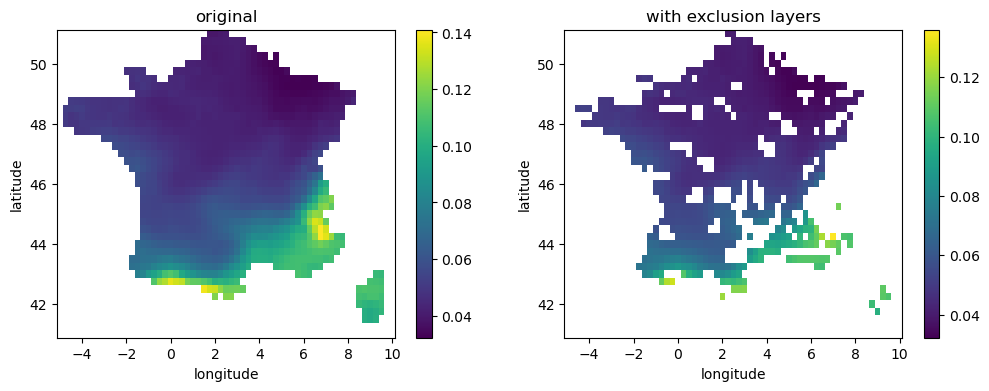

In [16]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
plt.title("spv capacity factor")
# time averaged original spv
country_spv.mean(dim='time').plot(ax=ax[0])
ax[0].set_title("original")
# time averaged spv masked with exclusion layers
country_spv_exc.mean(dim='time').plot(ax=ax[1])
ax[1].set_title("with exclusion layers")

We can see from the plots that some pixels have been removed; of course for this country there are no polar areas, nor there are high slope areas, but there are certainly high-altitude areas in the Alps and Pyrenees, and protected areas that have been removed.

Now it is time to calculate the aggregate values of spv. We will do this both for the original data without the exclusion layers and for our spv calculated using the exclusion mask defined above, using the float region_mask datarray as weight for the weighted average:

In [17]:
# aggregate without exclusion layers
spv_aggr = (da_spv*region_mask).sum(dim=['latitude','longitude'])/region_mask.sum()
spv_aggr = spv_aggr.compute()
# aggregate WITH exclusion layers
spv_aggr_exc = (country_spv_exc*region_mask).sum(dim=['latitude','longitude'])/region_mask.sum()
spv_aggr_exc = spv_aggr_exc.compute()

We will now select from the dataarrays only values corrsponding to daylight hours, from 8 AM to 5 PM:

In [18]:
start_hour, end_hour = 8, 17
spv_aggr_light = spv_aggr.where((spv_aggr.time.dt.hour>=start_hour) & (spv_aggr.time.dt.hour<=end_hour))
spv_aggr_exc_light = spv_aggr_exc.where((spv_aggr.time.dt.hour>=start_hour) & (spv_aggr.time.dt.hour<=end_hour))

Now we can plot the two vesions of spv capacity factor, both hourly values and daily averages, using xarray resample method:

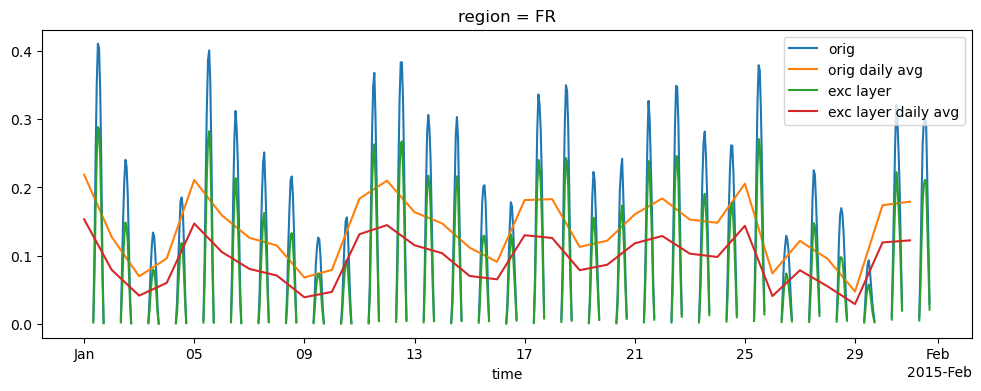

In [19]:
plt.figure(figsize=(12,4))
# spv_aggr.plot(label='orig')
# spv_aggr_exc.plot(label='exc layer')
# plot original spv hourly data
spv_aggr_light.plot(label='orig')
# plot original spv daily average
spv_aggr_light.resample(time='1D').mean().plot(label='orig daily avg')
# plot exclusion layers spv hourly data
spv_aggr_exc_light.plot(label='exc layer')
# plot exclusion layers spv daily average
spv_aggr_exc_light.resample(time='1D').mean().plot(label='exc layer daily avg')
plt.legend()

We can see that the effect of using exclusion layers mask is to decrease the average daily value of spv, mainly because high altitude points where spv is particularly high have been excluded form the aggregation; on the average, the decrease of the mean daily capacity factor for the selected month is around 28%

In [20]:
((spv_aggr_exc_light-spv_aggr_light)/spv_aggr_light).mean()

<xarray.DataArray ()> Size: 8B
array(-0.35474551)
Coordinates:
    region   <U4 16B 'FR'

We can take a look at what happend during the day by grouping data by hour of the day and taking the mean:

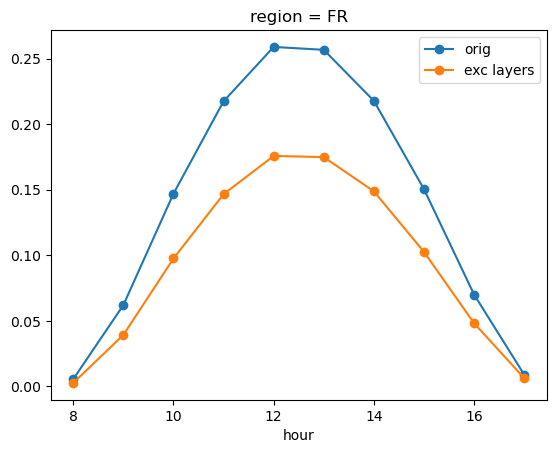

In [21]:
spv_aggr_light.groupby('time.hour').mean().plot(marker='o', label='orig')
spv_aggr_exc_light.groupby('time.hour').mean().plot(marker='o', label='exc layers')
plt.legend()

The graph above shows how a correct assessment of the appropriate position can affect the resulting capacity factor values, which might otherwise be overestimated.

## Take home messages 📌

* In current operational implementations of the C3S Energy service, wind and solar power indicators (SPV, WON, WOF) are computed at every grid point of the domain and aggregated without making use of exclusion layers;
* To take into account the suitability of locations, different types of exclusion layers can be used for more realistic modelling of energy indicators.